In [1]:
import numpy as np
from sklearn.linear_model import LinearRegression
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
cData = pd.read_csv(r"C:\Users\DELL\Downloads\auto-mpg.csv")
cData.shape

(398, 9)

In [3]:
cData.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [4]:
cData = cData.drop('car name', axis=1)
cData['origin'] = cData['origin'].replace({1: 'america', 2: 'europe', 3: 'asia'})
cData.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
0,18.0,8,307.0,130,3504,12.0,70,america
1,15.0,8,350.0,165,3693,11.5,70,america
2,18.0,8,318.0,150,3436,11.0,70,america
3,16.0,8,304.0,150,3433,12.0,70,america
4,17.0,8,302.0,140,3449,10.5,70,america


In [5]:
cData = pd.get_dummies(cData, columns=['origin'])
cData.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin_america,origin_asia,origin_europe
0,18.0,8,307.0,130,3504,12.0,70,True,False,False
1,15.0,8,350.0,165,3693,11.5,70,True,False,False
2,18.0,8,318.0,150,3436,11.0,70,True,False,False
3,16.0,8,304.0,150,3433,12.0,70,True,False,False
4,17.0,8,302.0,140,3449,10.5,70,True,False,False


In [6]:
cData.describe()

,mpg,cylinders,displacement,weight,acceleration,model year
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000


In [7]:
cData.dtypes

mpg               float64
cylinders           int64
displacement      float64
horsepower         object
weight              int64
acceleration      float64
model year          int64
origin_america       bool
origin_asia          bool
origin_europe        bool
dtype: object

In [8]:
hpIsDigit = pd.DataFrame(cData.horsepower.str.isdigit())
cData[hpIsDigit['horsepower'] == False]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin_america,origin_asia,origin_europe
32,25.0,4,98.0,?,2046,19.0,71,True,False,False
126,21.0,6,200.0,?,2875,17.0,74,True,False,False
330,40.9,4,85.0,?,1835,17.3,80,False,False,True
336,23.6,4,140.0,?,2905,14.3,80,True,False,False
354,34.5,4,100.0,?,2320,15.8,81,False,False,True
374,23.0,4,151.0,?,3035,20.5,82,True,False,False


In [9]:
cData = cData.replace('?', np.nan)
cData[hpIsDigit['horsepower'] == False]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin_america,origin_asia,origin_europe
32,25.0,4,98.0,NaN,2046,19.0,71,True,False,False
126,21.0,6,200.0,NaN,2875,17.0,74,True,False,False
330,40.9,4,85.0,NaN,1835,17.3,80,False,False,True
336,23.6,4,140.0,NaN,2905,14.3,80,True,False,False
354,34.5,4,100.0,NaN,2320,15.8,81,False,False,True
374,23.0,4,151.0,NaN,3035,20.5,82,True,False,False


In [10]:
cData['horsepower'] = cData['horsepower'].astype('float64')

In [11]:
cData.median()

mpg                 23.0
cylinders            4.0
displacement       148.5
horsepower          93.5
weight            2803.5
acceleration        15.5
model year          76.0
origin_america       1.0
origin_asia          0.0
origin_europe        0.0
dtype: float64

In [12]:
medianFiller = lambda x: x.fillna(x.median())
cData = cData.apply(medianFiller,axis=0)

cData['horsepower'] = cData['horsepower'].astype('float64')

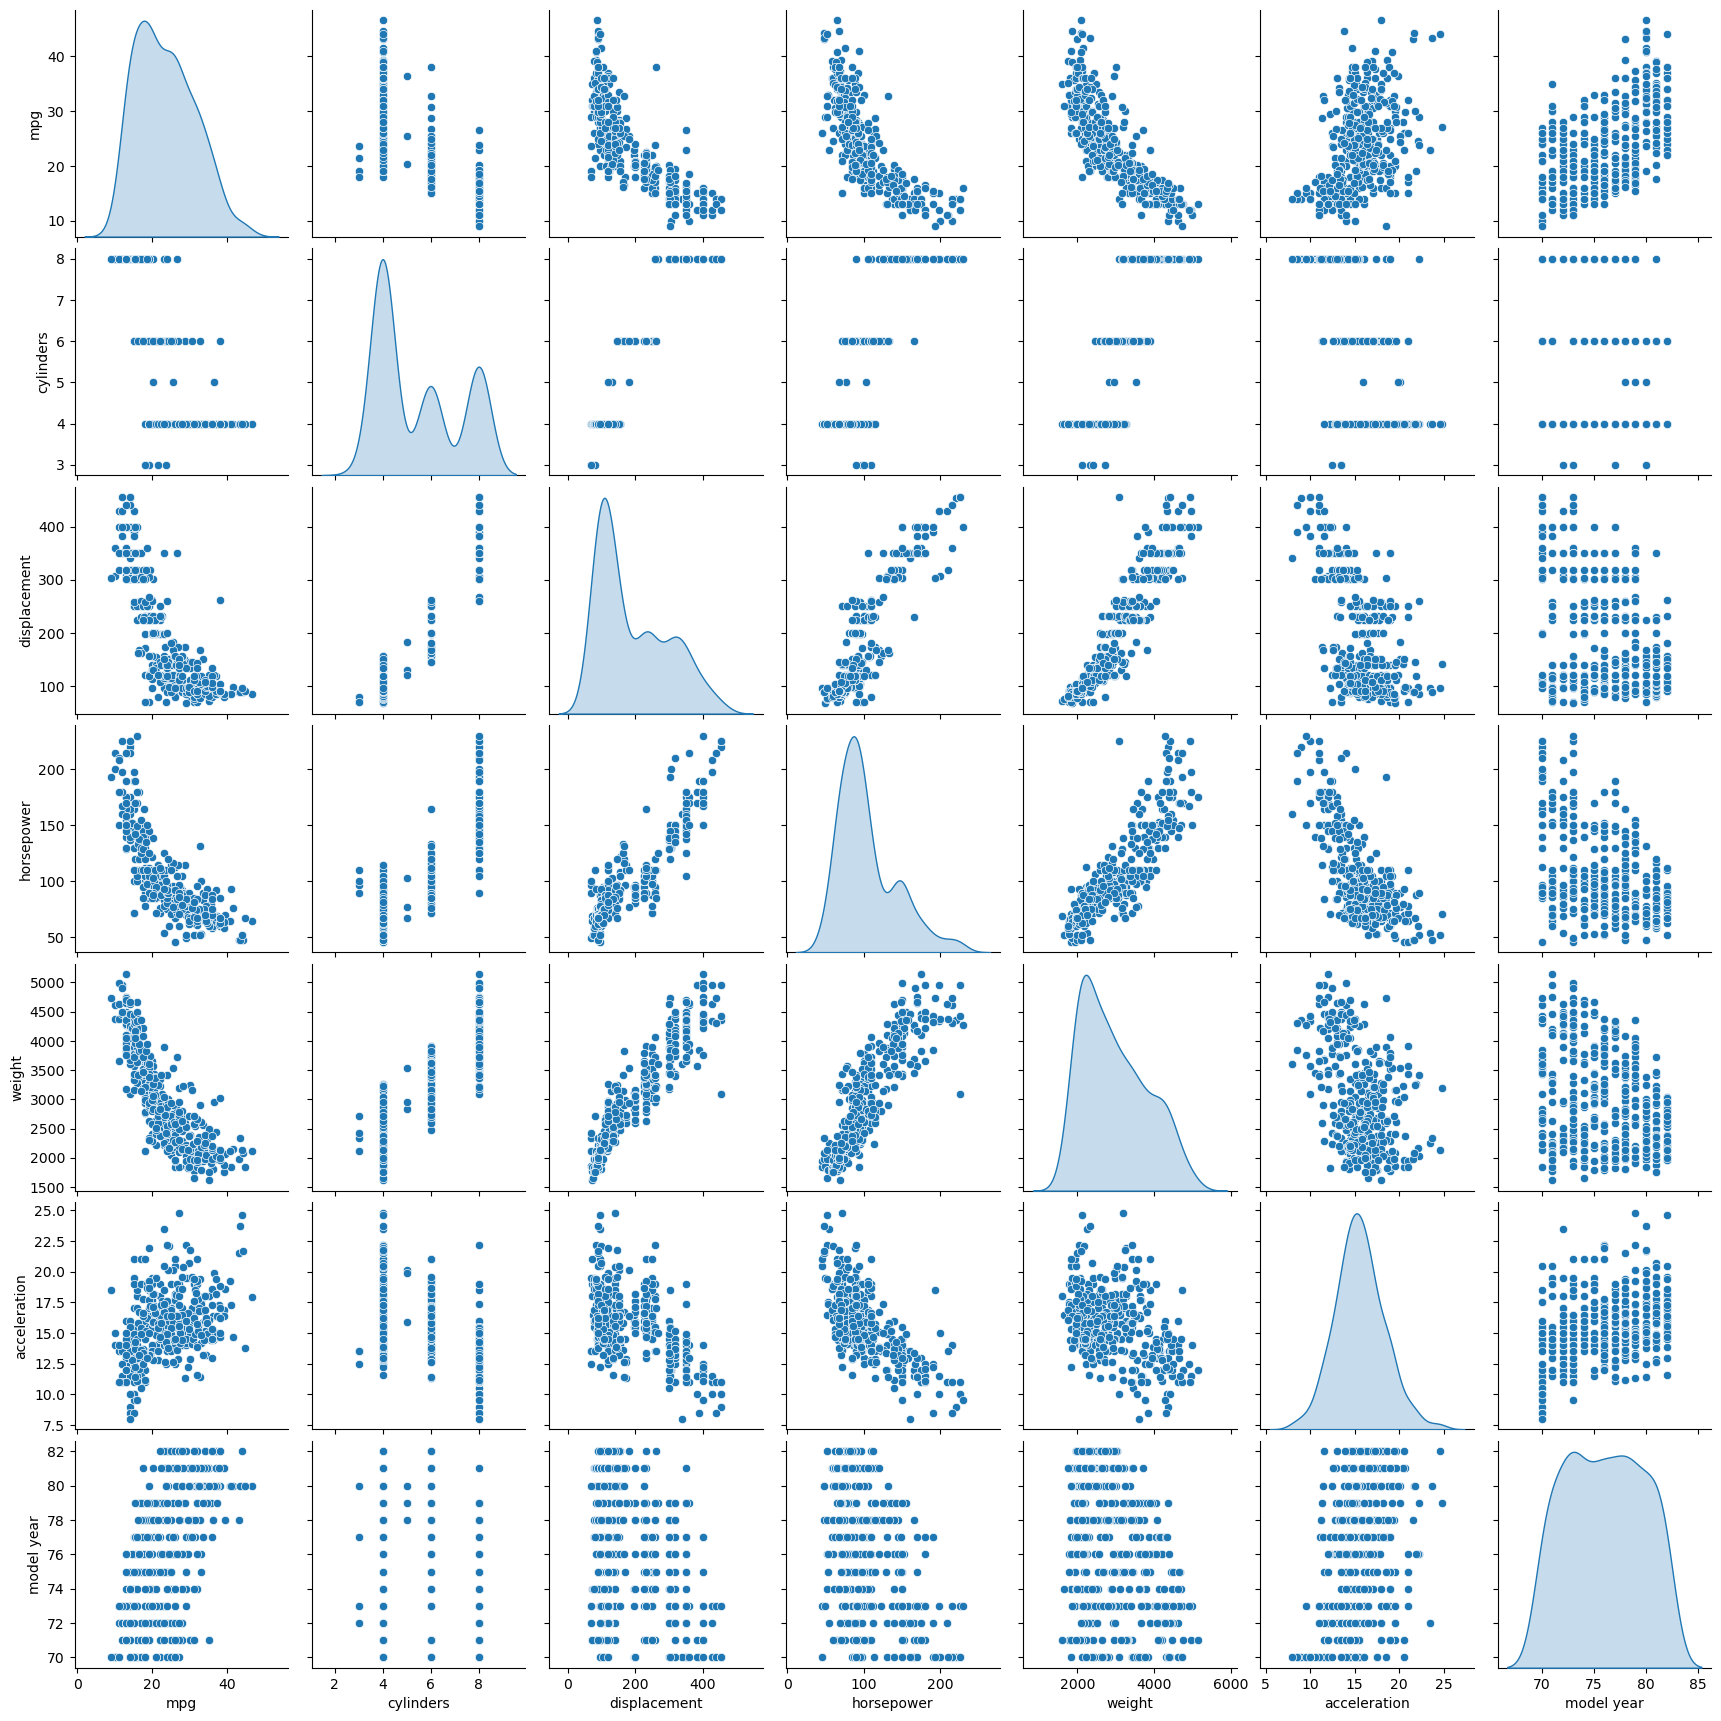

In [13]:
cData_attr = cData.iloc[:, 0:7]
sns.pairplot(cData_attr,diag_kind='kde')
plt.show()

In [14]:
X = cData.drop(['mpg','origin_europe'], axis=1)
y = cData[['mpg']]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=1)

In [16]:
regression_model = LinearRegression()
regression_model.fit(X_train, y_train)

LinearRegression()

In [17]:
for idx, col_name in enumerate(X_train.columns):
    print("The coefficient for {} is {}".format(col_name, regression_model.coef_[0][idx]))

The coefficient for cylinders is -0.39480796616482455
The coefficient for displacement is 0.02894551076548739
The coefficient for horsepower is -0.02175220772354734
The coefficient for weight is -0.007352032065147343
The coefficient for acceleration is 0.061919366007618125
The coefficient for model year is 0.8369338917645
The coefficient for origin_america is -3.001283000918513
The coefficient for origin_asia is -0.6060179643247408


In [18]:
intercept = regression_model.intercept_[0]
print("The intercept for our model is {}".format(intercept))

The intercept for our model is -18.28345111637211


In [19]:
regression_model.score(X_train, y_train)

0.8141025501610559

In [20]:
regression_model.score(X_test, y_test)

0.8433135132808829

In [21]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn import linear_model

poly = PolynomialFeatures(degree=2, interaction_only=True)
X_train2 = poly.fit_transform(X_train)
X_test2 = poly.fit_transform(X_test)

poly_clf = linear_model.LinearRegression()

poly_clf.fit(X_train2, y_train)

y_pred = poly_clf.predict(X_test2)

print(poly_clf.score(X_train2, y_train))

0.9026446935642733


In [22]:
print(poly_clf.score(X_test2, y_test))

0.8668600518057472


In [23]:
print(X_train.shape)
print(X_train2.shape)

(278, 8)
(278, 37)


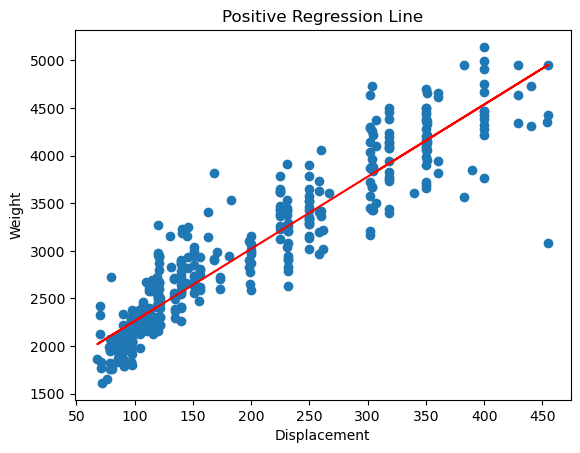

7.576059092261052


In [31]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


X = cData[['displacement']]
y = cData['weight']

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

plt.scatter(X, y)
plt.plot(X, y_pred, color='red')

plt.xlabel("Displacement")
plt.ylabel("Weight")
plt.title("Positive Regression Line")
plt.show()

print(model.coef_[0])